# FMoW-WILDS extent statistics by region

Does the HR image's spatial extent (`img_span_km`) differ systematically for Africa versus the other WILDS regions?

In [29]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from average_class_extent import load_metadata, REGION_NAMES

AFRICA = 2
REGION_ORDER = sorted(REGION_NAMES) 

HIGHLIGHT = "#e34948"  
DEFAULT = "#2a78d6"    
GRID = "#e1e0d9"
INK = "#0b0b0b"
SECONDARY = "#52514e"


def region_color(region_idx: int) -> str:
    return HIGHLIGHT if region_idx == AFRICA else DEFAULT


def style_axes(ax):
    ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(colors=SECONDARY)
    ax.xaxis.label.set_color(SECONDARY)
    ax.yaxis.label.set_color(SECONDARY)
    ax.title.set_color(INK)

In [31]:
df = load_metadata(split="all", region=None)
df["region_name"] = df["region"].map(REGION_NAMES)

print(f"Total WILDS samples with a matched extent: {len(df):,}")
print(df["region_name"].value_counts().reindex([REGION_NAMES[r] for r in REGION_ORDER]))

Total WILDS samples with a matched extent: 141,696
region_name
Asia        32201
Europe      58824
Africa       5377
Americas    41765
Oceania      3469
Other          60
Name: count, dtype: int64


## Per-region extent summary

`img_span_km` is the ground distance covered by the HR crop - larger span means the same 224x224 image covers more ground, thus coarser effective resolution.

In [3]:
summary = df.groupby("region")["img_span_km"].agg(
    n="count", mean="mean", median="median", std="std", min="min", max="max"
)
summary.index = summary.index.map(REGION_NAMES)
summary = summary.reindex([REGION_NAMES[r] for r in REGION_ORDER])
summary = summary.sort_values("mean", ascending=False)

with pd.option_context("display.float_format", lambda x: f"{x:.4f}"):
    print(summary)

print(
    f"\nAll regions pooled: mean={df['img_span_km'].mean():.4f} km, "
    f"median={df['img_span_km'].median():.4f} km"
)

              n   mean  median    std    min    max
region                                             
Other        60 0.7191  0.3706 1.0002 0.3660 4.8896
Africa     5377 0.6074  0.4374 0.7282 0.3993 4.9752
Asia      32201 0.5087  0.4151 0.4919 0.2883 4.9707
Oceania    3469 0.4978  0.4177 0.5178 0.3472 4.9444
Americas  41765 0.4559  0.4150 0.3336 0.2137 4.9719
Europe    58824 0.3572  0.3219 0.2629 0.1363 4.0435

All regions pooled: mean=0.4338 km, median=0.3842 km


## Distribution shape by region

Density-normalized histograms to compare.

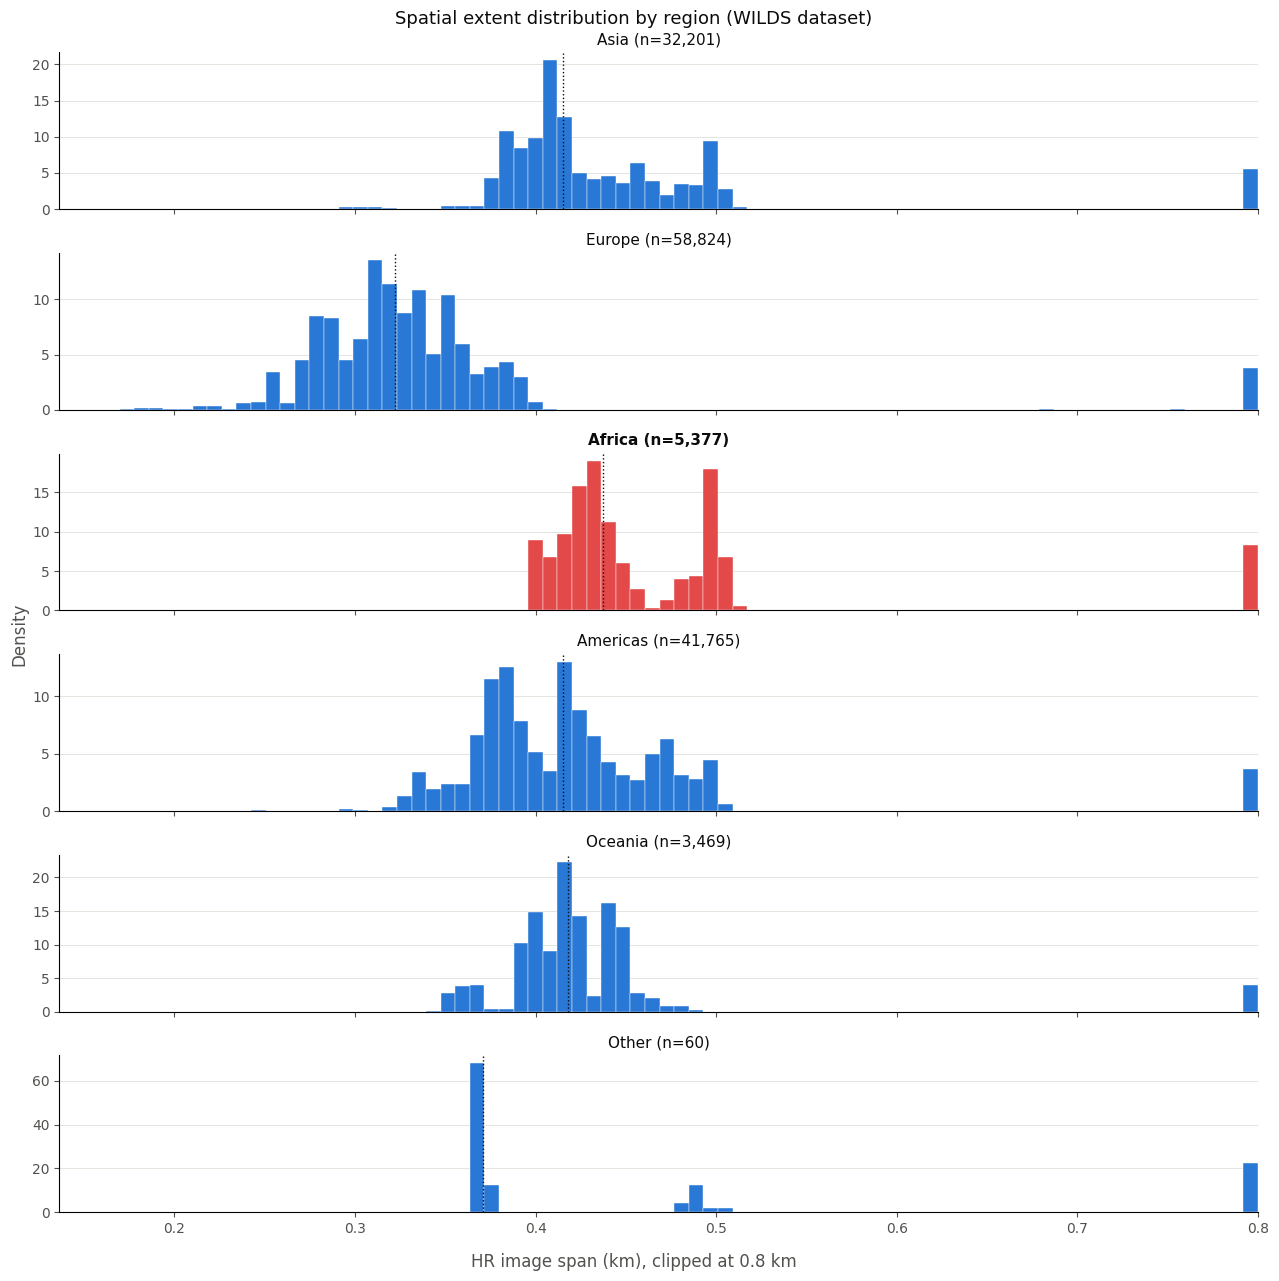

In [17]:
XMIN = df["img_span_km"].min()
XMAX = 0.8
bins = np.linspace(0, XMAX, 100)

fig, axes = plt.subplots(6, 1, figsize=(13, 13), sharex=True, sharey=False)
for ax, r in zip(axes.flat, REGION_ORDER):
    sub = df.loc[df["region"] == r, "img_span_km"]
    ax.hist(sub.clip(upper=XMAX), bins=bins, color=region_color(r),
            edgecolor="white", linewidth=0.3, density=True)
    ax.axvline(sub.median(), color=INK, linestyle=":", linewidth=1)
    ax.set_title(f"{REGION_NAMES[r]} (n={len(sub):,})", fontsize=11,
                 fontweight="bold" if r == AFRICA else "normal",
                 color=HIGHLIGHT if r == AFRICA else INK)
    axes.flat[0].set_xlim(left=XMIN, right=XMAX)
    style_axes(ax)

fig.supxlabel(f"HR image span (km), clipped at {XMAX} km", color=SECONDARY)
fig.supylabel("Density", color=SECONDARY)
fig.suptitle("Spatial extent distribution by region (WILDS dataset)", fontsize=13, color=INK)
fig.tight_layout()
plt.show()

## Regional effect or different class mix?

Africa's class distribution differs a lot from the rest of the world's (e.g. relatively more `crop_field`, less `parking_lot`), and different classes naturally have different footprints (an `airport` is bigger than a `single-unit_residential`). So: does Africa's higher extent survive *within the same class*, or is it just class-mix?

For every class with >=20 Africa samples, compare Africa's mean extent to the rest-of-world mean extent for that *same* class, then run a paired Wilcoxon signed-rank test across classes (paired because each class contributes one Africa estimate and one rest-of-world estimate).

In [28]:
africa_df = df[df["region"] == AFRICA]
rest_df = df[df["region"] != AFRICA]

africa_class = africa_df.groupby("category")["img_span_km"].agg(n_africa="count", mean_africa="mean")
rest_class = rest_df.groupby("category")["img_span_km"].agg(n_rest="count", mean_rest="mean")

paired = africa_class.join(rest_class, how="inner")
paired = paired[paired["n_africa"] >= 20].copy()
paired["diff_km"] = paired["mean_africa"] - paired["mean_rest"]

n_classes = len(paired)
n_higher = int((paired["diff_km"] > 0).sum())

print(f"Classes with >=20 Africa samples: {n_classes}")
print(f"Classes where Africa extent > rest-of-world extent (same class): {n_higher}/{n_classes}")
print(f"Mean paired difference: {paired['diff_km'].mean():.4f} km  (median {paired['diff_km'].median():.4f} km)")

top_k = 43 
print(f"\nTop {top_k} classes by |Africa - others| extent gap:")
with pd.option_context("display.float_format", lambda x: f"{x:.3f}"):
    print(paired.sort_values("diff_km", key=np.abs, ascending=False).head(top_k)
          [["n_africa", "mean_africa", "mean_rest", "diff_km"]])

Classes with >=20 Africa samples: 43
Classes where Africa extent > rest-of-world extent (same class): 41/43
Mean paired difference: 0.1027 km  (median 0.0795 km)

Top 43 classes by |Africa - others| extent gap:
                               n_africa  mean_africa  mean_rest  diff_km
category                                                                
port                                 45        4.385      3.785    0.600
airport                             106        4.650      4.281    0.370
runway                              111        1.363      1.074    0.289
amusement_park                       50        1.199      0.930    0.269
impoverished_settlement              38        1.480      1.320    0.160
smokestack                           25        0.436      0.314    0.122
barn                                 30        0.447      0.338    0.109
flooded_road                         26        0.484      0.375    0.109
office_building                      49        0.471      0